# TODOS:
* Apply match_cpu function/logic for recommended requirements column
* Implement KNN classifier to don't need K-Means model retraining
* Recommend Hardware based on game

In [1]:
import pandas as pd
import numpy as np
import re
import plotly.express as px
from thefuzz import process, fuzz
%autosave 60

Autosaving every 60 seconds


In [2]:
df = pd.read_csv("../../../datasets/processed/mergedDF.csv")

In [3]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25847 entries, 0 to 25846
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   appid    25847 non-null  int64
 1   name     25847 non-null  str  
 2   min_req  25841 non-null  str  
 3   rec_req  24603 non-null  str  
dtypes: int64(1), str(3)
memory usage: 15.8 MB


In [5]:
df.head()

,appid,name,min_req,rec_req
0,10,Counter-Strike,", Minimum: 500 mhz processor, 96mb ram, 16mb v...",NaN
1,70,Half-Life,", Minimum: 500 mhz processor, 96mb ram, 16mb v...",NaN
2,220,Half-Life 2,"Minimum: , OS *: Windows 7, Vista, XP, Process...",NaN
3,240,Counter-Strike: Source,", Minimum: 1.7 GHz Processor, 512MB RAM, Direc...",NaN
4,400,Portal,", Minimum: 1.7 GHz Processor, 512MB RAM, Direc...",NaN


In [6]:
df[df['appid'] == 1962700]

,appid,name,min_req,rec_req
22042,1962700,Subnautica 2,"Minimum: , OS: Windows 10/11, Processor: Intel...","Recommended: , OS: Windows 11, Processor: Inte..."


In [7]:
def extract_cpu(text):
    """Extract CPU info from Processor line."""
    CPU_LINE_PATTERN = r'(?i)(?:Processor|CPU):[,\s]+([^,]+)'
    if pd.isna(text):
        return None
    text = str(text)
    match = re.search(CPU_LINE_PATTERN, text)
    if match:
        return match.group(1).strip()
    return None

In [8]:
def extract_gpu(text):
    if pd.isna(text):
        return None
    idx = text.find('Graphics')
    if idx == -1:
        idx = text.find('Video')
        offset = 6 # "Video:" (6 chars offset)
        if idx == -1:
            return None
    else:
        offset = 9 # "Graphics:" (9 chars offset)
    comma = 0
    txt = ''
    for c in text[idx:]:
        if c == ',':
            comma+=1
            if text[idx:].index(c) != offset:
                break
        if comma == 2:
            break
        txt += c
    if "RAM" in txt[offset+1:]:
        return None
    return txt[offset+1:]

In [9]:
def clean_mac_req(text):
    if pd.isna(text):
        return None
    tmp = text
    min_count = 0
    for i, idx in zip(tmp.split(','), range(len(tmp.split(',')))):
        if 'Minimum:' in i:
            min_count+=1
        if min_count > 1:
            return ','.join(tmp.split(',')[:idx])
    return text

In [10]:
df['min_req'] = df['min_req'].apply(lambda x: clean_mac_req(x))

In [11]:
df['min_gpu'] = df['min_req'].apply(lambda x: extract_gpu(x))

In [12]:
df['min_cpu'] = df['min_req'].apply(lambda x: extract_cpu(x))

In [13]:
df.isna().sum()

appid         0
name          0
min_req       6
rec_req    1244
min_gpu    4712
min_cpu    1413
dtype: int64

---

In [14]:
benchdf = pd.read_csv("../../../datasets/raw/CPU_UserBenchmarks.csv")

In [15]:
benchdf.head()

,Type,Part Number,Brand,Model,Rank,Benchmark,Samples,URL
0,CPU,BX8071514900KS,Intel,Core i9-14900KS,1,133.0,1592,https://cpu.userbenchmark.com/SpeedTest/229530...
1,CPU,BX8071514900KF,Intel,Core i9-14900KF,2,131.0,7773,https://cpu.userbenchmark.com/SpeedTest/221221...
2,CPU,BX8071514900K,Intel,Core i9-14900K,3,131.0,19876,https://cpu.userbenchmark.com/Intel-Core-i9-14...
3,CPU,BX8071513900KS,Intel,Core i9-13900KS,4,131.0,4204,https://cpu.userbenchmark.com/SpeedTest/200081...
4,CPU,BX8071514700KF,Intel,Core i7-14700KF,5,130.0,4842,https://cpu.userbenchmark.com/SpeedTest/221202...


In [16]:
benchdf = benchdf[['Brand', 'Model', 'Benchmark']]

In [17]:
benchdf.drop(benchdf[benchdf['Brand'].str.contains('Snapdragon')].index, inplace=True)

In [18]:
benchdf.drop(benchdf[benchdf['Model'].str.contains('APU')].index, inplace=True)

In [19]:
cpu_bench = dict(zip(benchdf['Brand'] + " " + benchdf['Model'], benchdf['Benchmark']))
cpu_bench['Intel Core i7 4700'] = cpu_bench['Intel Core i7-4700MQ']
cpu_bench['Intel Core i5-3400'] = cpu_bench['Intel Core i5-3427U']
cpu_bench

{'Intel Core i9-14900KS': 133.0,
 'Intel Core i9-14900KF': 131.0,
 'Intel Core i9-14900K': 131.0,
 'Intel Core i9-13900KS': 131.0,
 'Intel Core i7-14700KF': 130.0,
 'Intel Core i7-14700K': 130.0,
 'Intel Core i9-13900KF': 129.0,
 'Intel Core i9-13900K': 129.0,
 'AMD Ryzen 7 9800X3D': 128.0,
 'Intel Core i7-13700KF': 126.0,
 'Intel Core i7-13700K': 126.0,
 'Intel Core i9-14900': 124.0,
 'Intel Core i9-14900F': 124.0,
 'Intel Core i5-14600KF': 124.0,
 'Intel Core i9-13900F': 124.0,
 'Intel Core i5-14600K': 124.0,
 'Intel Core i9-13900': 123.0,
 'Intel Core i5-13600K': 122.0,
 'Intel Core i5-13600KF': 122.0,
 'Intel Core Ultra 9 285K': 121.0,
 'Intel Core i7-14700F': 121.0,
 'Intel Core i7-14700': 121.0,
 'AMD Ryzen 7 7800X3D': 121.0,
 'Intel Core i7-13700F': 121.0,
 'Intel Core i7-13700': 121.0,
 'AMD Ryzen 9 9950X3D': 120.0,
 'Intel Core i9-12900KS': 119.0,
 'Intel Core Ultra 7 265KF': 119.0,
 'AMD Ryzen 9 9900X3D': 119.0,
 'Intel Core Ultra 7 265K': 119.0,
 'AMD Ryzen 9 9950X': 118.0,


In [20]:
def clean_cpu_string(text):
    if pd.isna(text):
        return
    # 1. Remove símbolos de marca registrada e caracteres especiais
    text = re.sub(r'[®™©@]', '', text)
    # Remove frequencies (e.g., 2.66 GHz, 3.2GHz, @ 2.0 GHz)
    text = re.sub(r'(?i)@?\s*\d+\.?\d*\s*[gm]hz', '', text)
    # Remove core counts in parentheses (e.g., (2 * 2660))
    text = re.sub(r'\(\d+\s*\*\s*\d+\)', '', text)
    # Replace 3rd and 4th by 3000 4000
    text = re.sub(r'(?i)3rd', '3000', text)
    text = re.sub(r'(?i)4rd', '4000', text)
    # 2. Remove ruídos comuns que confundem o fuzzy match
    noise = [
        'or better', 'or equivalent', 'or higher processor', 
        'equivalent', 'processor', 'generation'
    ]
    for word in noise:
        text = re.compile(re.escape(word), re.IGNORECASE).sub('', text)

    text = re.sub(r'\(\s*\d+\s*\*?\s*\d+(?:\s*[gm]hz)?\s*\)', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\(64[\s-]?bit\)', '', text, flags=re.IGNORECASE)
    
    return text.strip()

In [21]:
def bench_gpu_score(text):
    if pd.isna(text):
        return None

In [22]:
df['min_cpu'] = df['min_cpu'].apply(lambda x: clean_cpu_string(x))

In [23]:
def cpu_match(text, score_dict, confidence=False):
    if pd.isna(text):
        return np.nan
    
    # SPLITTING
    # Split by "or", "|", or "/" to separate Intel and AMD mentions
    parts = re.split(r'\s+or\s+|/|\|', text)
    
    matched_cpus = []
    
    # FUZZY MATCHING 
    for part in parts:
        clean_part = part.strip(' ()') # clean trailing spaces and brackets
        if not clean_part or not any(char.isalnum() for char in clean_part):
            continue
        if len(clean_part) < 3 or not re.search(r'\d{3,}', clean_part): 
            continue # Skip empty or tiny strings like "i3" without brand or missing model like "Intel Core i3"
            
        # Extract the best match from our dictionary keys
        best_match, match_accuracy = process.extractOne(clean_part, score_dict.keys())
        
        # Only accept the match if it's confident enough (e.g., 80% similarity)
        if match_accuracy > 90:
            matched_cpus.append({
                "raw_string": part.strip(),
                "matched_model": best_match,
                "score": score_dict[best_match],
                "confidence": match_accuracy
            })
    if matched_cpus and confidence:
        return max(matched_cpus, key=lambda x: x['score'])['confidence']
    if matched_cpus:
        return max(matched_cpus, key=lambda x: x['score'])['score']

    return cpu_match_generics(text, confidence=confidence)

In [24]:
def cpu_match_generics(text, confidence=False):
    if not text or not any(char.isalnum() for char in text):
        return None
    generics_score = {
        'i3': 36.1,
        'Intel Dual Core': 33.9,
        'Intel Core i3': 36.1,
        'Duo Core': 30.9,
        'Dual Core': 30.9,
        'Intel Core i5': 39.4,
        'Core i5': 39.4,
        'Intel i5': 39.4,
        'P4': 23,
        'P3': 11,
        'Pentium III': 11,
        'Pentium 4': 23,
        'Pentium IV': 23,
        'i3 8100': 70.6
    }
    match, accuracy = process.extractOne(text, generics_score.keys())
    if accuracy > 80 and confidence:
        return accuracy // 2
    if accuracy > 80:
        return generics_score[match]
    return None

In [25]:
# Testing
# 3. Apply the function to the data
#frame = df.loc[df['cpu_bench'] > 80, ['min_cpu']].reset_index(drop=True)
#results = [cpu_match(row, cpu_bench) for row in frame['min_cpu']]
# Print results
#for i, res in enumerate(results):
#    print(f"Raw Row {i}: {frame['min_cpu'][i]}")
#    print(f"Matches: {res}\n")

In [26]:
df['cpu_bench_confidence'] = df['min_cpu'].apply(lambda x: cpu_match(x, cpu_bench, confidence=True))

In [27]:
df['cpu_bench'] = df['min_cpu'].apply(lambda x: cpu_match(x, cpu_bench))

---

In [28]:
df.drop(df[df['min_cpu'].isna()].index, inplace=True)
df.drop(df[df['min_cpu'] == 'Intel'].index, inplace=True)
df.drop(df[df['cpu_bench'].isna()].index, inplace=True)

In [29]:
df = df.reset_index(drop=True)

In [30]:
df.isna().sum()

appid                      0
name                       0
min_req                    0
rec_req                  773
min_gpu                 2771
min_cpu                    0
cpu_bench_confidence       0
cpu_bench                  0
dtype: int64

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19506 entries, 0 to 19505
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   appid                 19506 non-null  int64  
 1   name                  19506 non-null  str    
 2   min_req               19506 non-null  str    
 3   rec_req               18733 non-null  str    
 4   min_gpu               16735 non-null  str    
 5   min_cpu               19506 non-null  str    
 6   cpu_bench_confidence  19506 non-null  float64
 7   cpu_bench             19506 non-null  float64
dtypes: float64(2), int64(1), str(5)
memory usage: 12.8 MB


In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples

In [33]:
features = df[['cpu_bench']]

In [34]:
#X = StandardScaler().fit_transform(feature)
X = features
X

,cpu_bench
0,23.0
1,23.0
2,30.9
3,23.0
4,23.0
...,...
19501,33.9
19502,86.5
19503,39.4
19504,55.4


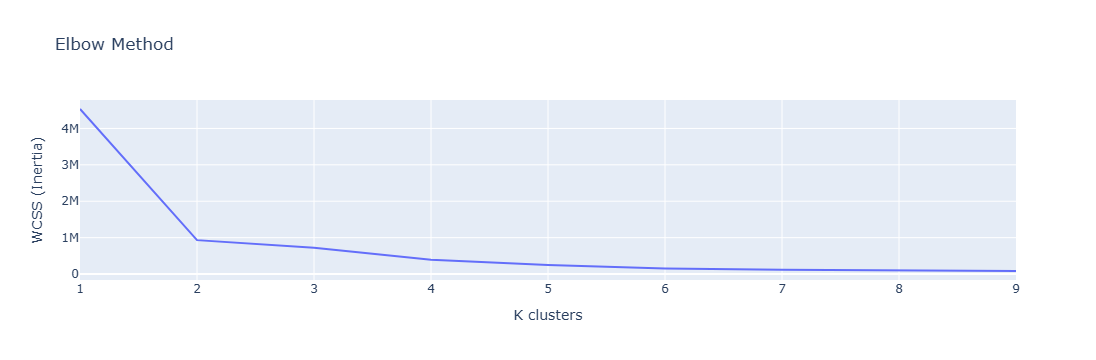

In [35]:
# Elbow Method
# Lista para armazenar os valores de inércia (WCSS)
n_clusters = range(1, 10)
kmeans = [KMeans(n_clusters=i, random_state=42).fit(X.values) for i in n_clusters]
wcss = [kmeans[i].inertia_ for i in range(len(kmeans))]

# Plotando o gráfico
pltdf = pd.DataFrame({'K clusters': n_clusters, 'WCSS (Inertia)': wcss})
px.line(pltdf, x='K clusters', y='WCSS (Inertia)', title='Elbow Method')

In [36]:
n_clusters = (5)-1 # (5) Cluster training number acquired by elbow method 

In [37]:
labels = kmeans[n_clusters].labels_
pd.Series(labels).unique()

array([2, 1, 4, 0, 3], dtype=int32)

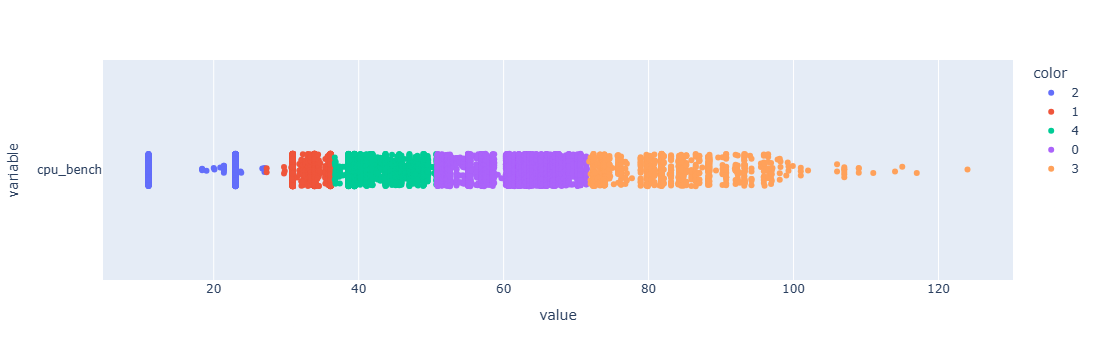

In [38]:
px.strip(X, color=labels, orientation='h', stripmode='overlay')

In [39]:
score_medio = silhouette_score(X, labels)
score_medio

0.6618524443470066

In [40]:
X_predicted = X.copy()
X_predicted['cluster'] = kmeans[n_clusters].predict(X.values)

In [41]:
df['cluster'] = kmeans[n_clusters].predict(X.values)

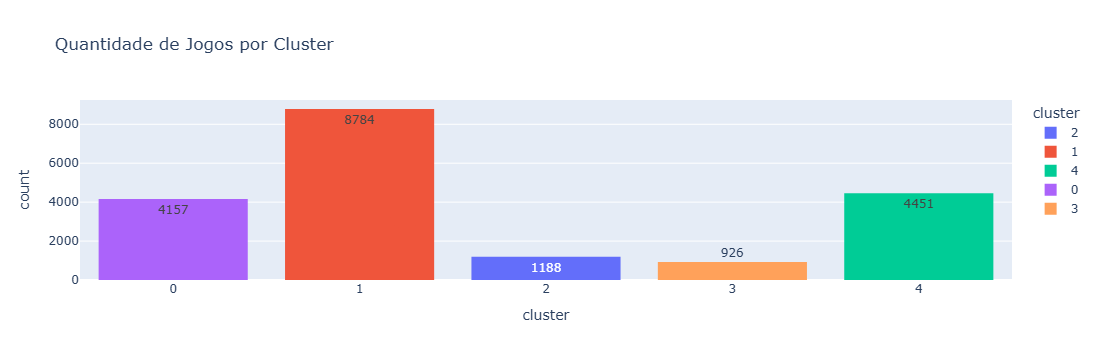

In [42]:
fig = px.histogram(df, x='cluster', color='cluster', text_auto=True, title="Quantidade de Jogos por Cluster")
fig.update_layout(bargap=0.2)

In [43]:
knn = NearestNeighbors(n_neighbors=3).fit(X.values)

In [44]:
def score_game_by_name(game: str):
    score = df[df['name'] == game]['cpu_bench']
    matches = process.extract(game, df['name'], limit=5)
    for i in range(len(matches)):
        print(f"Match {i+1}: {matches[i][0]}")
    if score.empty:
        match, accuracy, index = process.extractOne(game, df['name'])
        print(match + ",", "Confidence:", accuracy)
        if accuracy < 80:
            return None
        print(df[df['name'] == match][['min_cpu', 'cpu_bench']])
        return df[df['name'] == match]['cpu_bench'].to_numpy()
    return score.to_numpy()

In [45]:
score = score_game_by_name("No im not a human")
if score:
    neighbors = knn.kneighbors([score], return_distance=False)
    for i in neighbors:
        print(df.iloc[i]['min_cpu'])
else:
    print("Game not found")

Match 1: No, I'm not a Human
Match 2: S.T.A.L.K.E.R.: Shadow of Chernobyl
Match 3: F.E.A.R.
Match 4: F.E.A.R. 3
Match 5: S.T.A.L.K.E.R.: Call of Pripyat
No, I'm not a Human, Confidence: 94
             min_cpu  cpu_bench
17974  Intel core i5       39.4
157                                      Intel / AMD CPU
5      4 hardware CPU threads - Intel Core i5 750 or ...
73                                         Intel Core i5
Name: min_cpu, dtype: str


---

In [47]:
exceptions = [" ", ",", ":", "!", "?"]

In [48]:
df['name'] = df['name'].apply(lambda x: ''.join([c if c.isalnum() or c in exceptions else '' for c in list(x)]))
df['min_cpu'] = df['min_cpu'].apply(lambda x: re.sub(r'[()]', '', x))

In [49]:
# 13. Cluster labels and ranges (sorted by centroid)
centroids = kmeans[n_clusters].cluster_centers_.flatten()
cluster_order = np.argsort(centroids)
cluster_names = {cluster_order[0]: "Arcade",
                 cluster_order[1]: "Leve",
                 cluster_order[2]: "Mediano",
                 cluster_order[3]: "Pesado",
                 cluster_order[4]: "Gamer"}
cluster_ranges = {cluster_order[i]: f"{min(df[df['cluster'] == cluster_order[i]]['cpu_bench'])} - {max(df[df['cluster'] == cluster_order[i]]['cpu_bench'])}" for i in range(n_clusters+1)}
cluster_ranges

{np.int64(2): '11.0 - 27.0',
 np.int64(1): '27.3 - 36.5',
 np.int64(4): '36.7 - 50.7',
 np.int64(0): '50.9 - 71.5',
 np.int64(3): '71.8 - 124.0'}

In [50]:
import pickle

In [51]:
df.to_pickle("../../artifacts/games.pkl")
with open("../../artifacts/knn.pkl", "wb") as f:
    pickle.dump(knn, f)
with open("../../artifacts/kmeans.pkl", "wb") as f:
    pickle.dump(kmeans, f)
with open("../../artifacts/cluster_names.pkl", "wb") as f:
    pickle.dump(cluster_names, f)
with open("../../artifacts/cluster_ranges.pkl", "wb") as f:
    pickle.dump(cluster_ranges, f)
print("Artifacts saved to:", "../../artifacts/")
print("Cluster mapping:", cluster_names)

Artifacts saved to: ../../artifacts/
Cluster mapping: {np.int64(2): 'Arcade', np.int64(1): 'Leve', np.int64(4): 'Mediano', np.int64(0): 'Pesado', np.int64(3): 'Gamer'}
